# The 35-second first stage of the 2026 M7.4 Colombia earthquake
### Discovery, diagnosis, handling, and what it probably is

Companion to nb30 (`us6000tjl2`, 2026-08-10, Mww 7.4, 110 km deep, Cauca cluster). This notebook isolates the single most consequential property of this earthquake — it did **not** begin like a normal event — and documents, step by step, how that property was discovered through an inversion *failure*, verified against alternatives, handled methodologically, and what physical process the evidence favors. All numbers are reproduced live where practical.

**The one-paragraph version:** global networks picked a P onset at 12:34:28.1 at 4.844°N 76.242°W (110 km deep) — but the dominant moment release began only ~35 s later and ~29 km to the SSW. The implied migration speed (~0.8 km/s) is far below any rupture velocity, so a standard finite-fault inversion nucleating at the cataloged hypocentre is kinematically impossible — it fails in a diagnostic way. Re-anchoring the model at the W-phase centroid (in space *and* time) yields a clean, well-contained main-rupture model. The first stage itself is visible at 105/107 stations at high frequency yet carries ≤ a few percent of the moment — a signature favoring a **cascade of ordinary foreshock-like subevents** over slow aseismic nucleation.


In [1]:
import os
from IPython.display import Image, display
B = os.path.expanduser('~/works/17.Venezuela_2026')


## 1. The anatomy
Two clocks and two places, one earthquake. The 'apparent velocity' connecting them is the crux: 29 km in 34.5 s ≈ 0.8 km/s, kinematically impossible as continuous rupture propagation (allowed Vr here: 2.4–2.6 km/s).


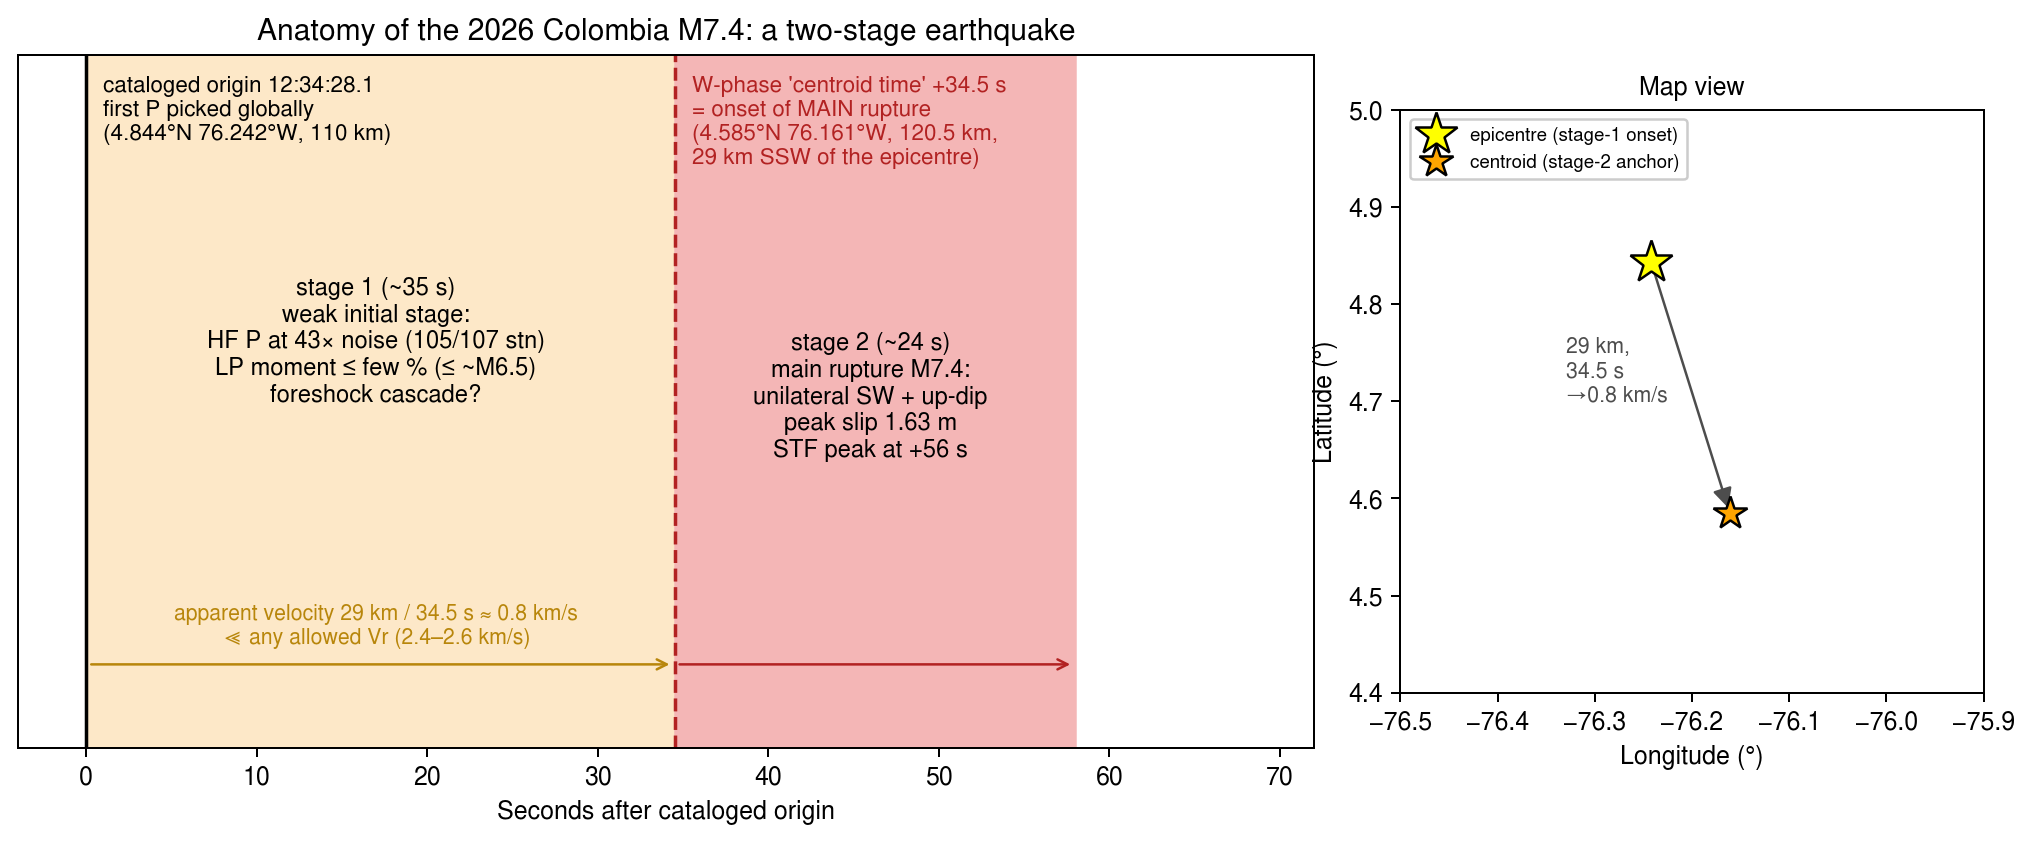

In [2]:
display(Image(os.path.join(B,'event_2026_colombia/fig_nucleation_anatomy.png')))


## 2. The raw evidence: two stages in every waveform
Before any inversion — band-passed vertical records aligned on the P arrival *predicted from the cataloged origin*, at all azimuths. Stage 1 arrives exactly on that move-out (so the cataloged origin is real, not an association artifact); the amplitude jumps ~35–40 s later when the main rupture begins. An independent back-projection analyst (K. Tarumi, ERI) read the same records as 'duration too long — two earthquakes overlapping?', with clear SW directivity — both observations consistent with what follows.


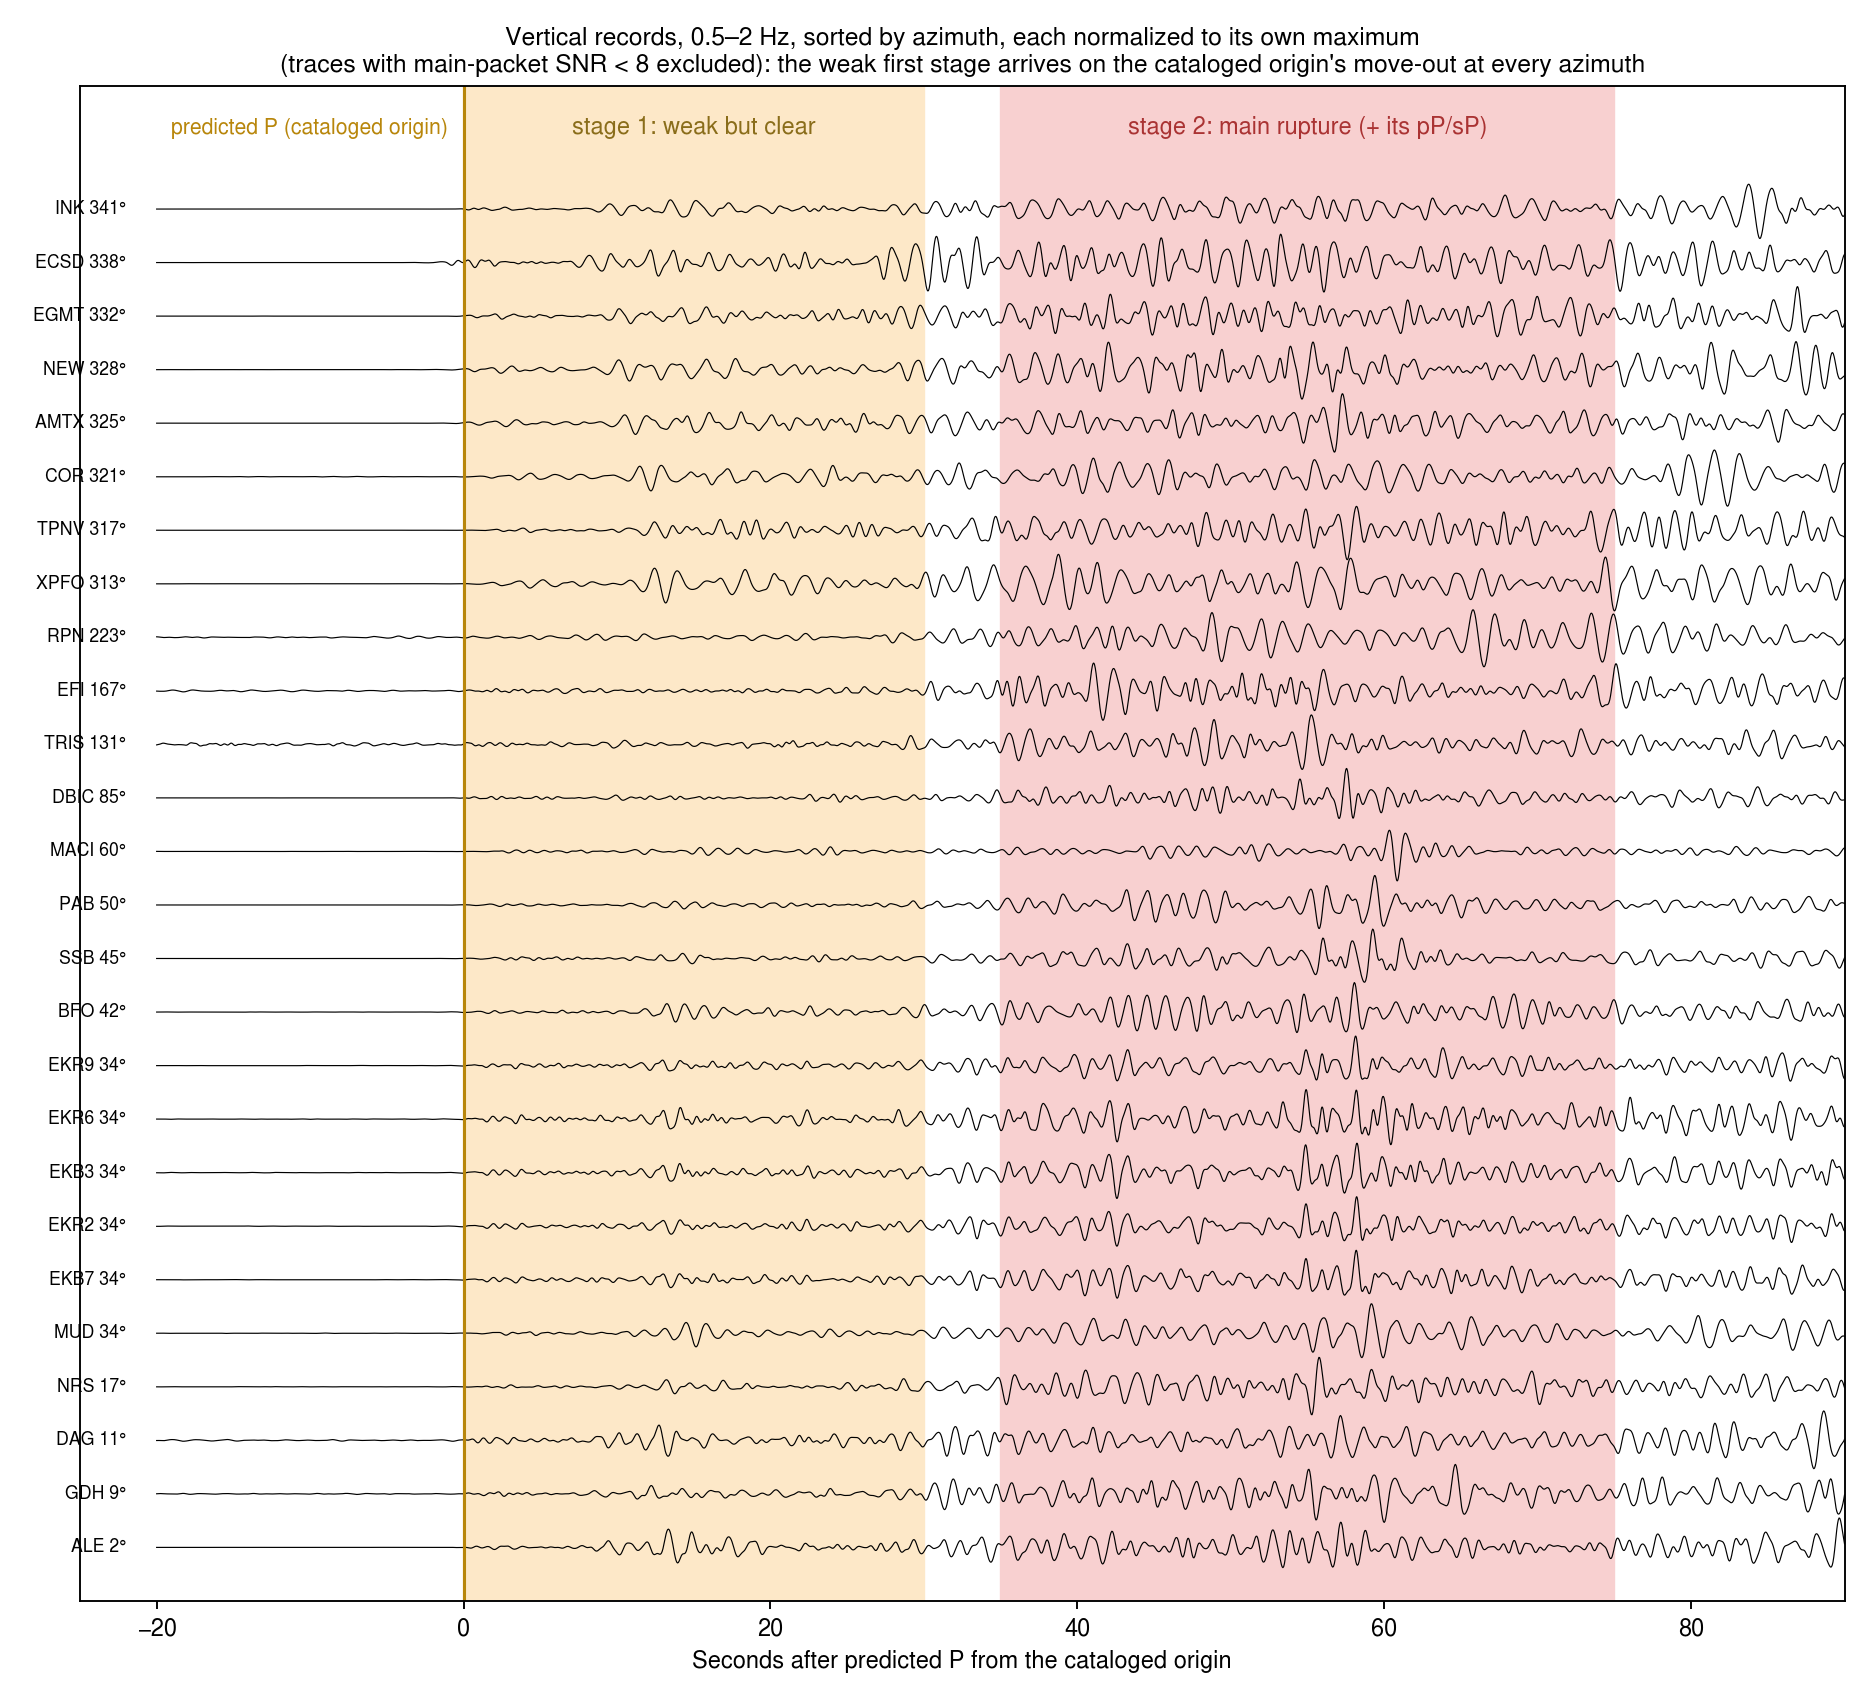

In [3]:
display(Image(os.path.join(B,'event_2026_colombia/fig_nucleation_recordsection.png')))


### Quantifying stage 1 against noise (live)
RMS in three windows relative to predicted P, 0.5–2 Hz, all usable stations 35–85°. This is the falsification test: if stage 1 were an artifact of a phantom origin, the early window would be at the noise level.


In [4]:
import glob, numpy as np, warnings
warnings.filterwarnings('ignore')
from obspy import read, UTCDateTime
from obspy.taup import TauPyModel
from obspy.geodetics import gps2dist_azimuth, kilometers2degrees
mod = TauPyModel('ak135')
O = UTCDateTime('2026-08-10T12:34:28.125'); elat, elon, edep = 4.8436, -76.2422, 110.3
E_, M_ = [], []
for f in sorted(glob.glob(os.path.join(B, 'event_2026_colombia/*_BHZ_*.sac'))):
    tr = read(f, format='sac')[0]; h = tr.stats.sac
    if h.get('stla') is None: continue
    m, az, _ = gps2dist_azimuth(elat, elon, h['stla'], h['stlo']); g = kilometers2degrees(m/1000)
    if not (35 < g < 85): continue
    arr = mod.get_travel_times(edep, g, ['P'])
    if not arr: continue
    tP = O + arr[0].time
    tr.detrend('demean'); tr.filter('bandpass', freqmin=0.5, freqmax=2.0, zerophase=True)
    def rms(a, b):
        s = tr.slice(tP+a, tP+b)
        return np.sqrt(np.mean(s.data**2)) if s.stats.npts > 10 else np.nan
    nz, e, mn = rms(-60, -15), rms(0, 25), rms(40, 75)
    if np.isnan(nz) or nz == 0: continue
    E_.append(e/nz); M_.append(mn/nz)
E_, M_ = np.array(E_), np.array(M_)
print(f'stations: {len(E_)}')
print(f'stage-1 window (0-25 s after predicted P): median {np.median(E_):.1f}x noise; detectable (>2x) at {(E_>2).sum()}/{len(E_)} stations')
print(f'stage-2 window (40-75 s): median {np.median(M_):.1f}x noise')
print(f'stage-1/stage-2 RMS ratio at 0.5-2 Hz: {np.median(E_/M_):.2f}')


stations: 107
stage-1 window (0-25 s after predicted P): median 43.3x noise; detectable (>2x) at 105/107 stations
stage-2 window (40-75 s): median 122.9x noise
stage-1/stage-2 RMS ratio at 0.5-2 Hz: 0.33


## 3. The diagnostic failure: what happens if you ignore it
A standard finite-fault inversion (WISP `auto_model`, nucleating at the cataloged hypocentre and origin time — exactly what any operational auto-run would do) *cannot* put moment where the data demand it: the only kinematically legal way to release moment late is far away. The inversion therefore fails in a characteristic, recognizable way — worth internalizing as the fingerprint of a delayed main rupture:
1. slip piles at the fault edge (86% of peak in an edge row — a violated containment rule);
2. the STF peaks at the *edge of the reachable time window* (~40 s);
3. synthetics fit only the long-period envelope of the records.

None of these is subtle. Any one of them should trigger the checks of section 1.


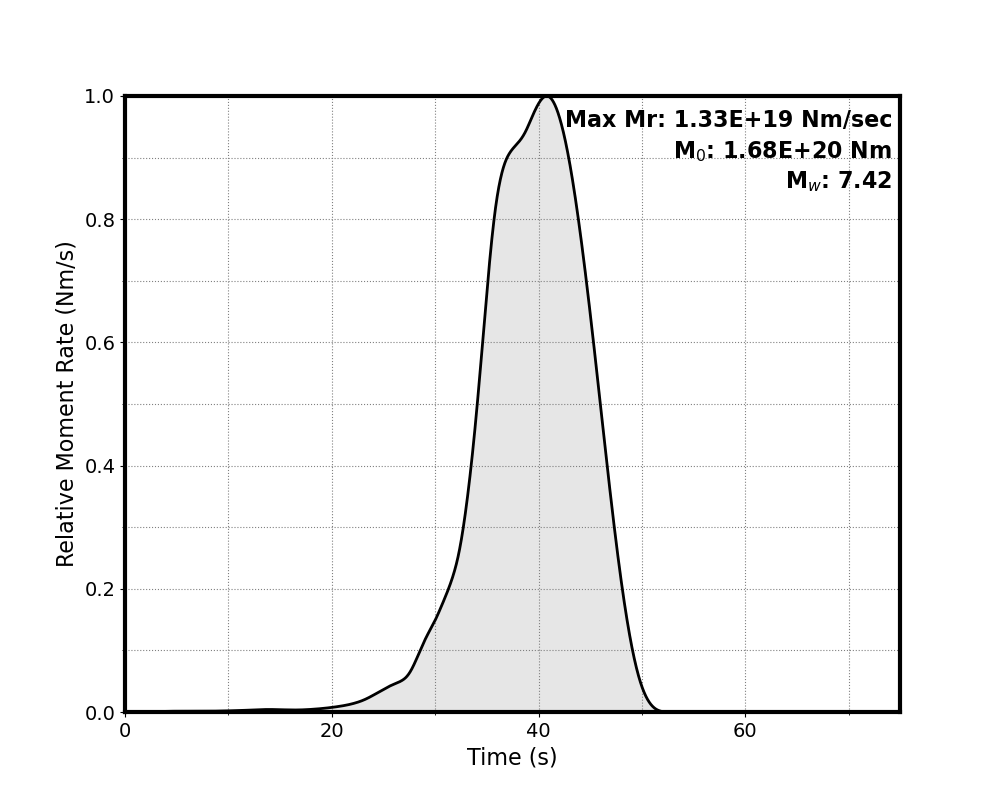

In [5]:
display(Image(os.path.join(B,'event_2026_colombia/20260810123428/ffm.0/NP1_shift/plots/MomentRate.png')))


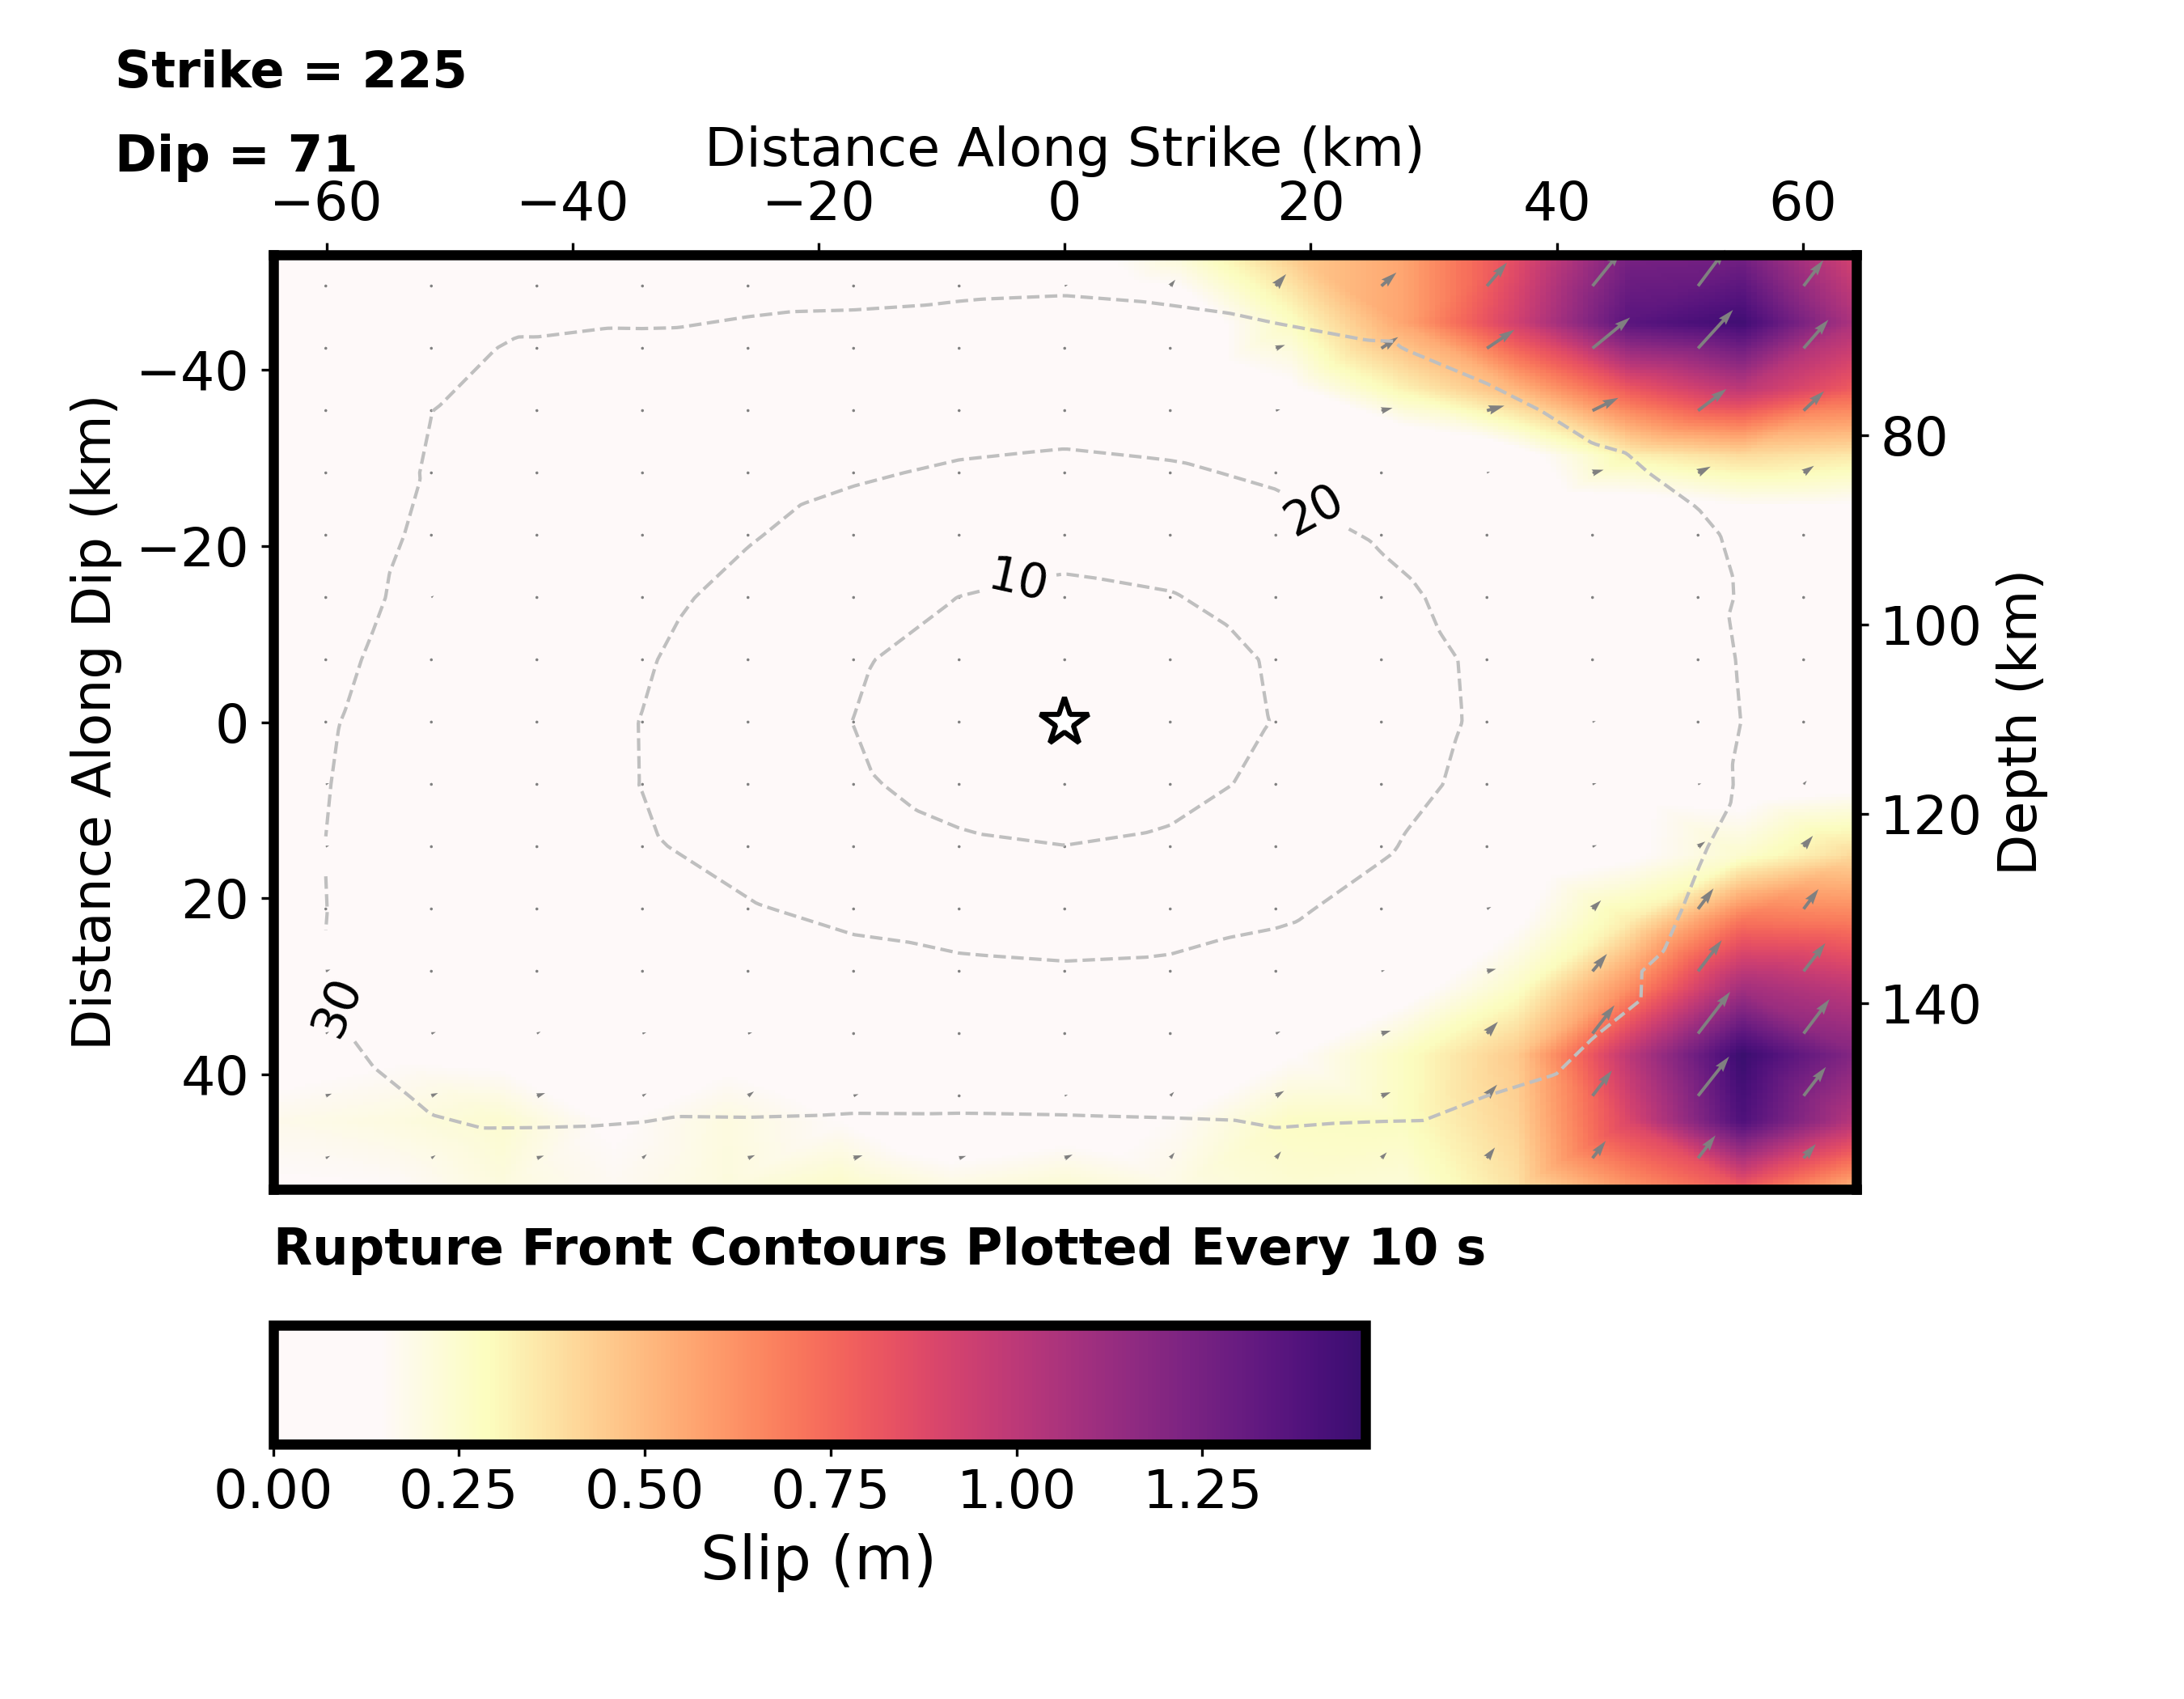

In [6]:
display(Image(os.path.join(B,'event_2026_colombia/20260810123428/ffm.0/NP1_shift/plots/SlipDist_plane0.png')))


## 4. The fix: re-anchor the model at the W-phase centroid — in space *and* time
The kinematic model's nucleation point is relocated from the cataloged hypocentre to the W-phase centroid (4.585°N, 76.161°W, 120.5 km) **and** the model origin time to the centroid time (12:35:02.6). The whole pipeline is re-run from scratch so window cutting, Green's functions, fault geometry and nucleation stay mutually consistent. Stage 1 then lies outside the modelling window and is *bounded* rather than imaged. Terminology note: this is what nb30 calls 'centroid-anchored'; the operational precedent is the USGS Yeck et al. (2023) recipe (relocate the finite fault to the geodetic centroid and nucleate there). Two subtleties:
- **The physical hypocentre is unchanged** — the earthquake really did start at the cataloged location; the model's nucleation is an *effective origin for the main subevent*.
- **The W-phase 'centroid time' is not a true whole-event moment centroid here.** Our main-phase moment-centroid lands at origin+51 s; if +34.5 s were a genuine centroid, stage 1 would need ~half the moment — flatly excluded by the M0 bookkeeping below. For a complex source the bounded W-phase time-shift effectively marks the *onset* of the main moment release — and the clean containment of the re-anchored inversion is the empirical proof that anchoring there was right.


### The re-anchored model, for contrast (full detail in nb30)


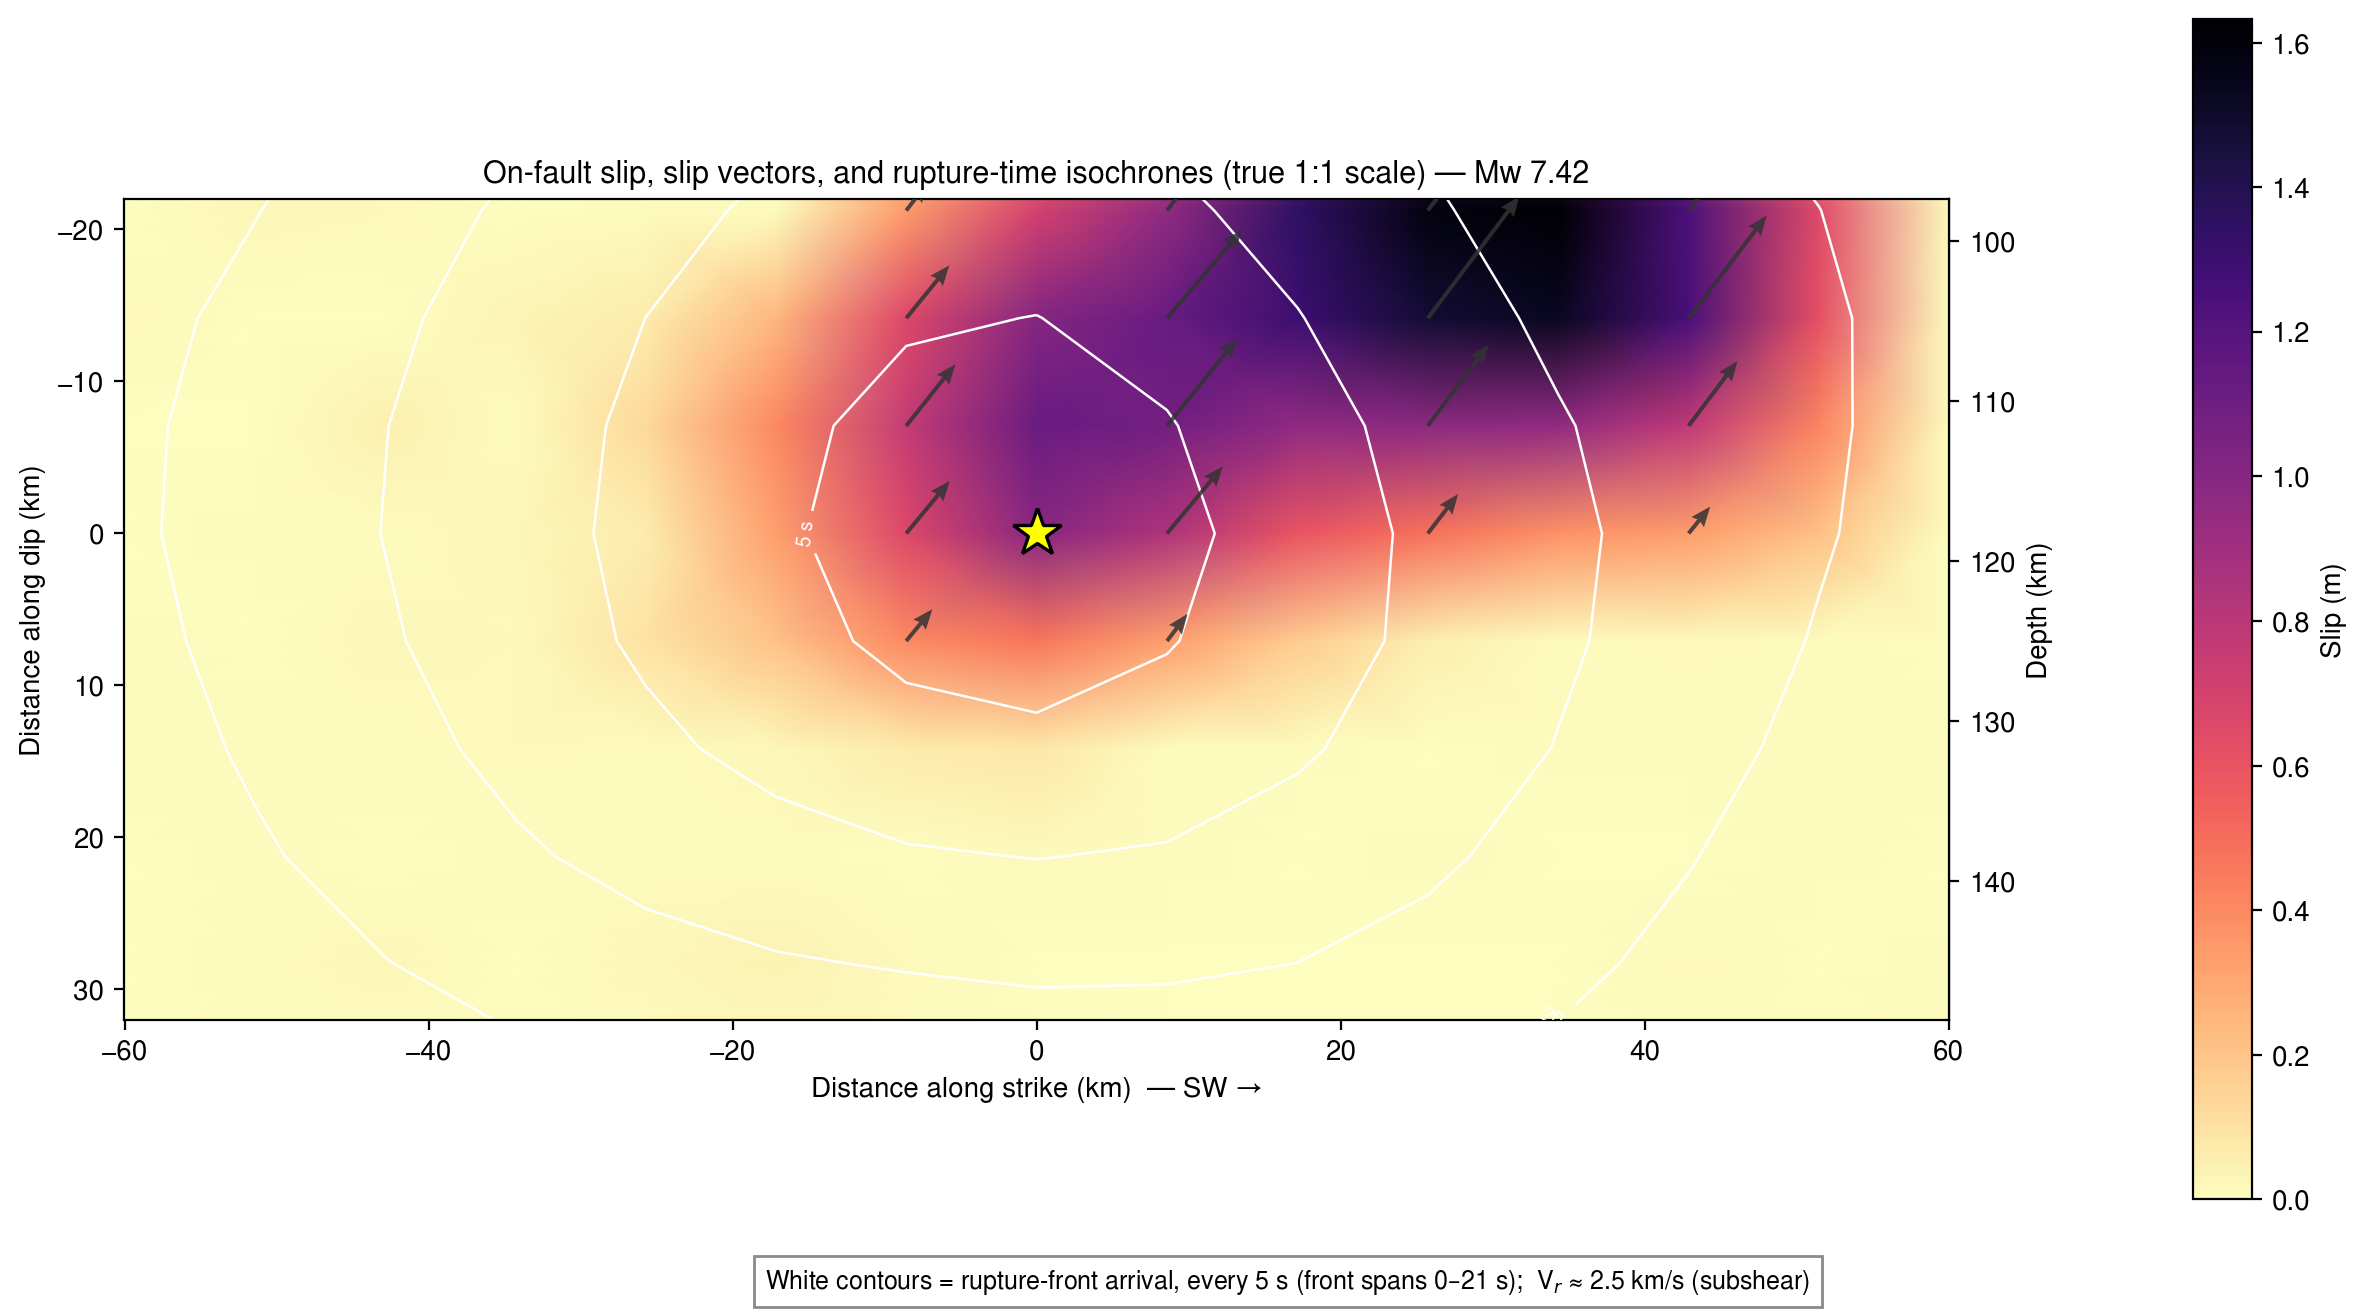

In [7]:
display(Image(os.path.join(B,'event_2026_colombia/20260810123502/ffm.0/NP1_shift/plots/SlipIsochrone_trueScale.png')))


## 5. Absolute-time bookkeeping and what stage 1 is
Left: the whole event on one clock — ~35 s of stage 1, then a ~24-s main rupture; total ~60 s (Tarumi's 'too-long duration'). Stage-1 moment is *bounded* by the agreement of the W-phase M0 (1.66×10²⁰ N·m, which sees the whole event at 100+ s periods) with our main-phase-only M0 (1.68×10²⁰): ≤ a few percent — though a few percent of an M7.4 still admits up to ~M6.4–6.5 of cumulative hidden moment.

Right: the discriminant. Stage 1 is **strong at high frequency** (~1/3 of the main phase in 0.5–2 Hz RMS) but **weak in long-period moment** (≤3%). Slow aseismic nucleation would be the opposite (LP-visible, HF-poor). HF-rich + LP-weak is the signature of *ordinary small ruptures* — an immediate **foreshock cascade** migrating toward the main asperity, individually too small to be cataloged separately but collectively radiating for ~35 s. The 'slow nucleation' label in this notebook's title therefore deserves its question mark: the evidence favors a cascade, not slow slip.


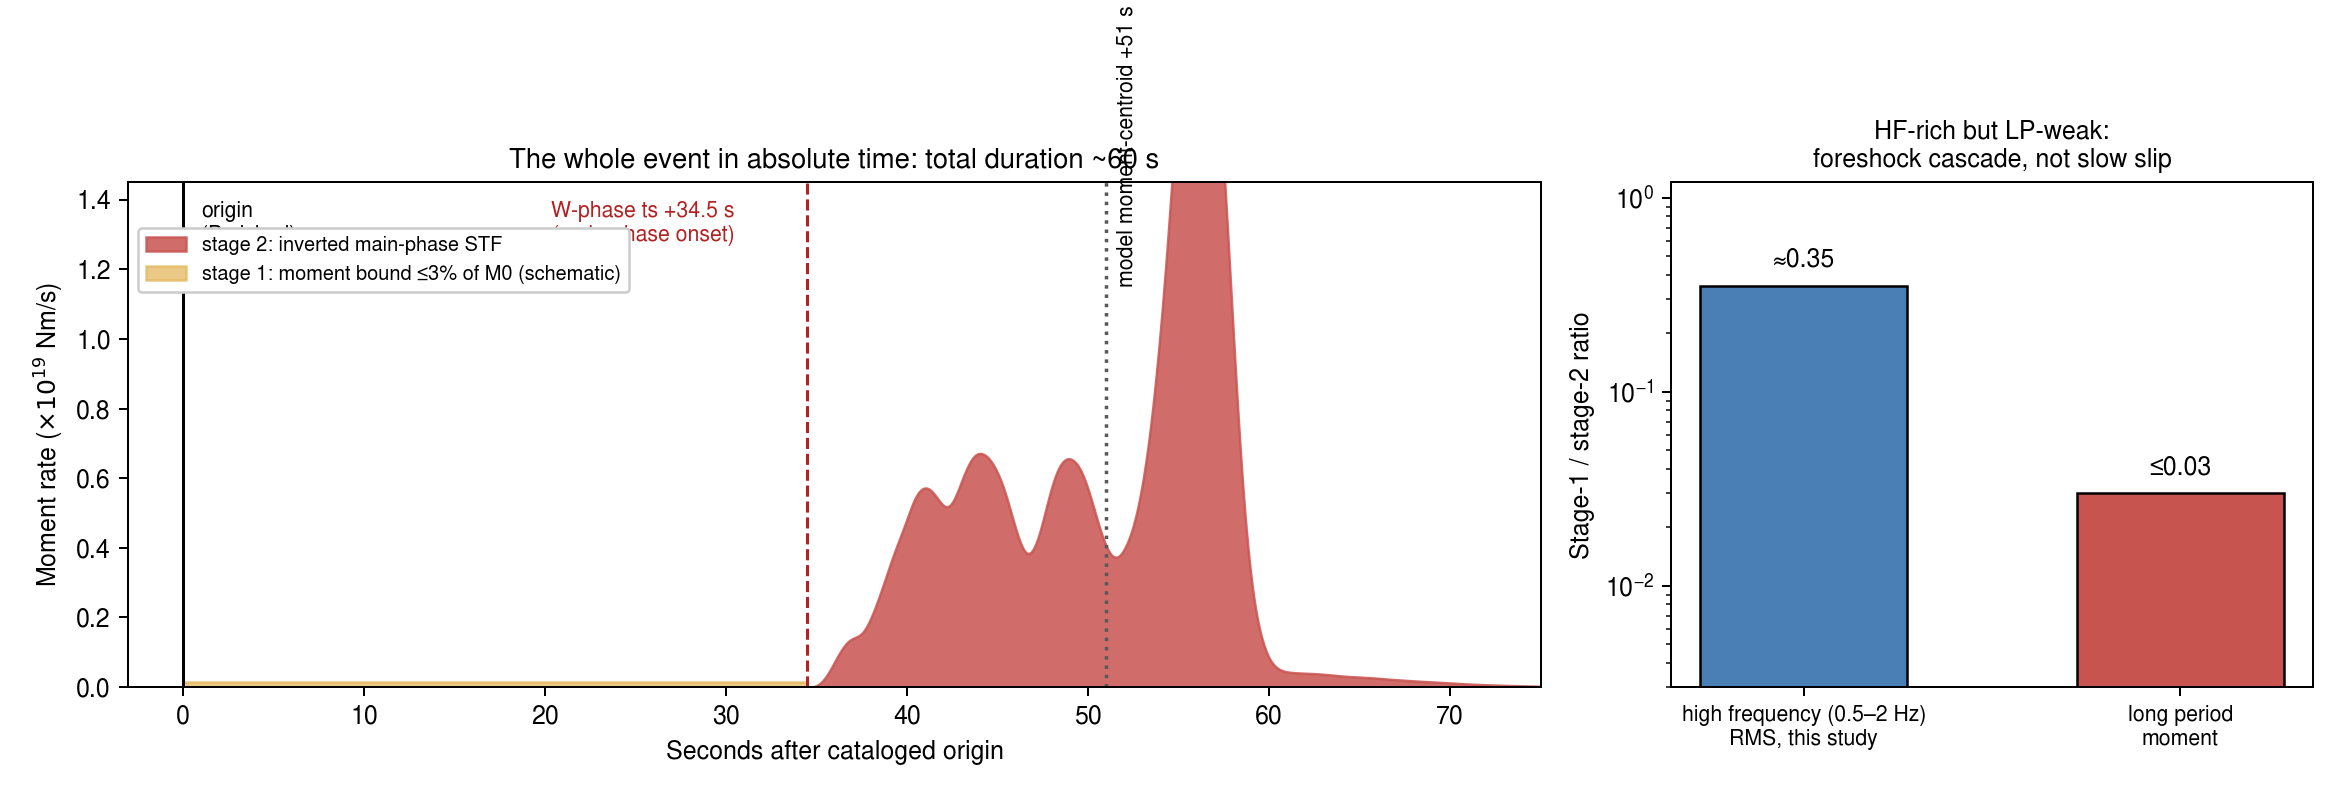

In [8]:
display(Image(os.path.join(B,'event_2026_colombia/fig_nucleation_stf_discrimination.png')))


## 6. Comprehensive summary

| item | value | status |
|---|---|---|
| stage-1 onset (cataloged origin) | 12:34:28.1, 4.844°N 76.242°W, 110 km | certain (global picks + 105/107-station move-out check) |
| stage-1 duration | ~35 s (±10 s on the main-phase onset) | robust |
| stage-1 HF visibility | median 43× noise (0.5–2 Hz, 107 stations) | measured here |
| stage-1 moment | ≤ few % of total (≤ ~M6.4–6.5 cumulative) | bounded by W-phase-vs-FFI M0 agreement |
| stage-1 nature | foreshock cascade favored over slow slip | inference (HF-rich, LP-weak) |
| main-phase onset | ~origin+34.5 s, 29 km SSW, ~120 km deep | W-phase anchor, validated by clean containment |
| main rupture | 226/72/33 plane, unilateral SW+up-dip, peak 1.63 m, ~24 s | nb30 |
| whole-event duration | ~60 s | consistent with independent BP reading |
| failure fingerprint (if ignored) | edge slip 86%, STF at window edge, envelope-only fits | reproduced deliberately |
| the fix | re-anchor nucleation at W-phase centroid in space and time | Yeck-style, validated |

**Open questions for the publication-level study:** where exactly did the cascade migrate (back-projection / matched filter on regional SGC data); is there a discrete largest foreshock subevent hidden in stage 1 (EGF deconvolution using the colocated 2019 M6.1); and does the USGS finite fault, when it appears, also relocate its nucleation?
